In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load the dataset
train = pd.read_csv("../artifacts/playground-series-s6e2/train.csv")
test = pd.read_csv("../artifacts/playground-series-s6e2/test.csv")
sample = pd.read_csv("../artifacts/playground-series-s6e2/sample_submission.csv")

train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [3]:
train.shape

(630000, 15)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [5]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [6]:
train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [7]:
test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [8]:
test.shape

(270000, 14)

In [9]:
X = train.drop(columns=["id", "Heart Disease"],axis=1)
y = train["Heart Disease"]
X_test = test.drop(columns=["id"],axis=1)

In [10]:
X_test.shape

(270000, 13)

In [11]:
# Split the data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [13]:
## Validation Score
pred_val = model.predict_proba(X_valid)[:,1]
print("AUC:", roc_auc_score(y_valid, pred_val))

AUC: 0.9482948934397196


In [14]:
pred_test = model.predict_proba(X_test)[:,1]

In [15]:
X_test.shape

(270000, 13)

In [16]:
pred_test.shape

(270000,)

In [17]:
test.shape

(270000, 14)

In [18]:
submission = pd.DataFrame({
    "id":test["id"],
    "Heart Disease": pred_test
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Heart Disease
0,630000,0.870
1,630001,0.000
2,630002,0.995
3,630003,0.020
4,630004,0.230


### Strong Baseline with LightGBM

In [19]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [20]:
import lightgbm as lgb

In [21]:
X = train.drop(columns=["id", "Heart Disease"],axis=1)
y = train["Heart Disease"]
X_test = test.drop(columns=["id"],axis=1)

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [23]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [24]:
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100)]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[808]	valid_0's auc: 0.95596	valid_0's binary_logloss: 0.266293


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1000,
               num_leaves=64, random_state=42, subsample=0.8)

In [25]:
# Validation Score
pred_val = model.predict_proba(X_valid)[:,1]
print("AUC:", roc_auc_score(y_valid, pred_val))

AUC: 0.9559595305781625


In [26]:
# Predict on the test set
pred_test = model.predict_proba(X_test)[:,1]

In [27]:
pred_test.shape

(270000,)

In [28]:
# submission
submission = pd.DataFrame({
    "id":test["id"],
    "Heart Disease": pred_test
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Heart Disease
0,630000,0.955007
1,630001,0.010078
2,630002,0.985900
3,630003,0.006534
4,630004,0.186976


### LightGBM with Stratified K-Fold

In [29]:
from sklearn.model_selection import StratifiedKFold

In [30]:
# Create k-folds 
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [31]:
oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

In [32]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    print(f"Fold {fold+1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = lgb.LGBMClassifier(
        boosting_type = "gbdt",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100)]
    )

    # OOF
    oof[valid_idx] = model.predict_proba(X_valid)[:,1]

    # Test
    test_preds += model.predict_proba(X_test)[:,1] / skf.n_splits

Fold 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 422
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[819]	valid_0's auc: 0.955451	valid_0's binary_logloss: 0.267744
Fold 2
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number

In [33]:
# CV score
from sklearn.metrics import roc_auc_score
print("CV AUC:", roc_auc_score(y, oof))

CV AUC: 0.9551441030720377


In [34]:
# Submission
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": test_preds
})

submission.to_csv("submission.csv", index=False)

### Multi-seed ensemble

In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

X = train.drop(["id","Heart Disease"], axis=1)
y = train["Heart Disease"]

X_test = test.drop(["id"], axis=1)

In [36]:
seeds = [42, 2024, 777]

oof_final = np.zeros(len(X))
test_final = np.zeros(len(X_test))

In [42]:
feature_importances = []

In [43]:
for seed in seeds:

    print(f"\n===== SEED {seed} =====")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        print(f"Seed {seed} Fold {fold+1}")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMClassifier(
            boosting_type="gbdt",
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(100)]
        )

        importance_df = pd.DataFrame({
            "feature": X.columns,
            "importance": model.booster_.feature_importance(importance_type="gain"),
            "seed": seed,
            "fold": fold
        })

        feature_importances.append(importance_df)

        # OOF
        oof[valid_idx] = model.predict_proba(X_valid)[:,1]

        # Test
        test_preds += model.predict_proba(X_test)[:,1] / skf.n_splits

    # seed score
    seed_score = roc_auc_score(y, oof)
    print(f"Seed {seed} AUC:", seed_score)

    # accumulate
    oof_final += oof / len(seeds)
    test_final += test_preds / len(seeds)


===== SEED 42 =====
Seed 42 Fold 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 422
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[819]	valid_0's auc: 0.955451	valid_0's binary_logloss: 0.267744
Seed 42 Fold 2
[LightGBM] [Warning] Found whitespace in feature_names, replace wit

In [44]:
#Final CV score
print("FINAL AUC:", roc_auc_score(y, oof_final))

FINAL AUC: 0.9552641383445603


In [45]:
fi_df = pd.concat(feature_importances, axis=0)

In [46]:
fi_mean = (
    fi_df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

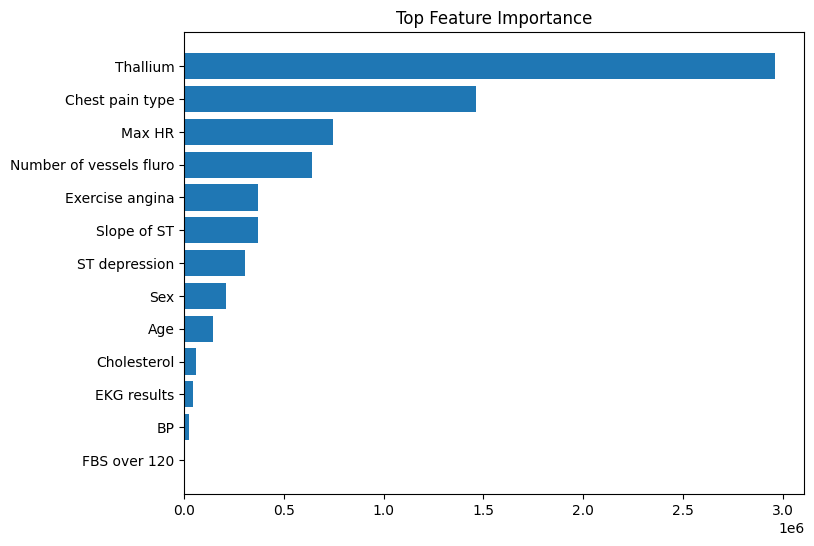

In [47]:
plt.figure(figsize=(8,6))
plt.barh(fi_mean["feature"][:15][::-1], fi_mean["importance"][:15][::-1])
plt.title("Top Feature Importance")
plt.show()

In [48]:
# Submission
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": test_preds
})

submission.to_csv("submission.csv", index=False)

### Feature Engineering Part

In [50]:
X.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Thallium_ChestPain,Thallium_MaxHR,Vessels_ChestPain
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,28,1106,8
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,3,513,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,6,453,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,9,450,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,12,375,12


In [53]:
# ==============================
# STEP 4 — FEATURE ENGINEERING
# ==============================

# Interaction features
for df in [train, test]:

    # Tier 1 (top importance interactions)
    df["Thallium_ChestPain"] = df["Thallium"] * df["Chest pain type"]
    df["Thallium_MaxHR"] = df["Thallium"] * df["Max HR"]
    df["Vessels_ChestPain"] = df["Number of vessels fluro"] * df["Chest pain type"]

    # Tier 2 (physiology interactions)
    df["Age_MaxHR"] = df["Age"] * df["Max HR"]
    df["Age_BP"] = df["Age"] * df["BP"]

    # Tier 3 (stress test interactions)
    df["STdep_Slope"] = df["ST depression"] * df["Slope of ST"]
    df["Angina_STdep"] = df["Exercise angina"] * df["ST depression"]

    # Ratio features (very powerful)
    df["Chol_BP_ratio"] = df["Cholesterol"] / (df["BP"] + 1)
    df["Age_MaxHR_ratio"] = df["Age"] / (df["Max HR"] + 1)

In [54]:
X = train.drop(["id", "Heart Disease"], axis=1)
y = train["Heart Disease"]

X_test = test.drop(["id"], axis=1)

print(X.shape, X_test.shape)

(630000, 22) (270000, 22)


In [55]:
seeds = [42, 2024, 777]

oof_final = np.zeros(len(X))
test_final = np.zeros(len(X_test))

In [56]:
feature_importances = []

In [57]:
for seed in seeds:

    print(f"\n===== SEED {seed} =====")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        print(f"Seed {seed} Fold {fold+1}")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMClassifier(
            boosting_type="gbdt",
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(100)]
        )

        importance_df = pd.DataFrame({
            "feature": X.columns,
            "importance": model.booster_.feature_importance(importance_type="gain"),
            "seed": seed,
            "fold": fold
        })

        feature_importances.append(importance_df)

        # OOF
        oof[valid_idx] = model.predict_proba(X_valid)[:,1]

        # Test
        test_preds += model.predict_proba(X_test)[:,1] / skf.n_splits

    # seed score
    seed_score = roc_auc_score(y, oof)
    print(f"Seed {seed} AUC:", seed_score)

    # accumulate
    oof_final += oof / len(seeds)
    test_final += test_preds / len(seeds)


===== SEED 42 =====
Seed 42 Fold 1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1851
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 22
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[654]	valid_0's auc: 0.95528	valid_0's binary_logloss: 0.26823
Seed 42 Fold 2
[LightGBM] [Warning] Found whitespace in feature_names, replace with

In [58]:
print("\nFINAL CV AUC:", roc_auc_score(y, oof))


FINAL CV AUC: 0.9549698159746955


In [59]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Heart Disease
0,630000,0.950355
1,630001,0.008532
2,630002,0.988336
3,630003,0.006293
4,630004,0.189969
